# Ensemble Model for Text Classification

This notebook handles the entire pipeline for training an ensemble model that combines multiple base models:
1. Data loading and preprocessing
2. Loading pre-trained base models
3. Building and training an ensemble model
4. Model evaluation and saving


In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint, ReduceLROnPlateau
from tensorflow.keras.optimizers import Adam
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix, roc_curve, auc
import re
import string
import nltk
from nltk.tokenize import word_tokenize
from nltk.corpus import stopwords
import keras_tuner as kt
import os
import pickle

nltk.download('punkt', quiet=True)
nltk.download('stopwords', quiet=True)

np.random.seed(2025)
tf.random.set_seed(2025)


2025-03-27 20:04:57.113070: I tensorflow/core/util/port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
2025-03-27 20:04:57.127407: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:477] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1743105897.144896  163259 cuda_dnn.cc:8310] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1743105897.150138  163259 cuda_blas.cc:1418] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
2025-03-27 20:04:57.169902: I tensorflow/core/platform/cpu_feature_guard.cc:210] This TensorFlow binary is optimized to use available CPU instr

## Data Preparation

In [2]:
print("Loading dataset...")
df = pd.read_csv("../../datasets/custom_dataset.csv", sep="\t")
print(f"Dataset shape: {df.shape}")
df.head()


Loading dataset...
Dataset shape: (5437, 2)


,Text,Label
0,"In mechanics, a variable-mass system is a coll...",Human
1,Variable-mass systems in fluids involve object...,AI
2,"Geomechanics (from the Greek γεός, i.e. prefix...",Human
3,Geomechanics studies the mechanical behavior o...,AI
4,Microscale chemistry (often referred to as sma...,Human


In [3]:
def clean_text(text):
    if not isinstance(text, str):
        return ""
    
    text = text.lower()
    
    text = re.sub(r"https?://\S+|www\.\S+|\S+@\S+\.\S+", "", text)
    
    text = re.sub(r"\s+", " ", text).strip()
    
    return text

df['cleaned_text'] = df['Text'].apply(clean_text)

df[['Text', 'cleaned_text']].sample(5)

labels = df['Label'].apply(lambda x: 0 if x == 'Human' else 1).values

print(f"Label distribution: {pd.Series(labels).value_counts().to_dict()}")

train_texts, temp_texts, train_labels, temp_labels = train_test_split(
    df['cleaned_text'].values, labels, test_size=0.3, random_state=2025, stratify=labels
)

val_texts, test_texts, val_labels, test_labels = train_test_split(
    temp_texts, temp_labels, test_size=0.5, random_state=2025, stratify=temp_labels
)

print(f"Training set: {len(train_texts)} samples")
print(f"Validation set: {len(val_texts)} samples")
print(f"Test set: {len(test_texts)} samples")


Label distribution: {1: 3461, 0: 1976}
Training set: 3805 samples
Validation set: 816 samples
Test set: 816 samples


In [4]:
max_words = 2500
max_seq_length = 128

tokenizer = Tokenizer(num_words=max_words, oov_token="<OOV>")
tokenizer.fit_on_texts(train_texts)

vocab_size = min(max_words, len(tokenizer.word_index) + 1)
print(f"Vocabulary size: {vocab_size}")

train_sequences = tokenizer.texts_to_sequences(train_texts)
val_sequences = tokenizer.texts_to_sequences(val_texts)
test_sequences = tokenizer.texts_to_sequences(test_texts)

train_padded = pad_sequences(train_sequences, maxlen=max_seq_length, padding='post', truncating='post')
val_padded = pad_sequences(val_sequences, maxlen=max_seq_length, padding='post', truncating='post')
test_padded = pad_sequences(test_sequences, maxlen=max_seq_length, padding='post', truncating='post')

def extract_features(texts):
    print("Extracting features...")
    features = []
    stop_words = set(stopwords.words("english"))
    
    for text in texts:
        if not isinstance(text, str) or not text.strip():
            features.append([0] * 8)
            continue
            
        words = word_tokenize(text)
        
        if not words:
            features.append([0] * 8)
            continue
            
        num_words = len(words)
        num_chars = len(text)
        avg_word_length = np.mean([len(w) for w in words]) if words else 0
        num_stopwords = sum(1 for word in words if word.lower() in stop_words)
        stopword_ratio = num_stopwords / num_words if num_words else 0
        
        num_punctuation = sum(1 for char in text if char in string.punctuation)
        punctuation_ratio = num_punctuation / num_chars if num_chars else 0
        
        lexical_diversity = len(set(words)) / num_words if num_words else 0
        
        feature_vector = [
            num_words,
            num_chars,
            avg_word_length,
            num_stopwords,
            stopword_ratio,
            num_punctuation,
            punctuation_ratio,
            lexical_diversity
        ]
        
        features.append(feature_vector)
        
    return np.array(features)

train_features = extract_features(train_texts)
val_features = extract_features(val_texts)
test_features = extract_features(test_texts)

print(f"Sequence data shape: {train_padded.shape}")
print(f"Feature data shape: {train_features.shape}")


Vocabulary size: 2500
Extracting features...
Extracting features...
Extracting features...
Sequence data shape: (3805, 128)
Feature data shape: (3805, 8)


## Load Pre-trained Models

In [5]:
model_paths = {
    'dnn': '../../trained_models/tensorflow/dnn_model.h5',
    'lstm': '../../trained_models/tensorflow/lstm_model.h5',
    'gru': '../../trained_models/tensorflow/gru_model.h5',
    'transformer': '../../trained_models/tensorflow/transformer_model.h5'
}

models_to_ensemble = []
model_inputs = []
model_names = []

for name, path in model_paths.items():
    if os.path.exists(path):
        print(f"Loading {name} model from {path}")
        model = keras.models.load_model(path)
        models_to_ensemble.append(model)
        model_names.append(name)
        
        if name == 'dnn':
            model_inputs.append(test_features)
        else:
            model_inputs.append(test_padded)
    else:
        print(f"Model {path} not found. Skipping.")

if len(models_to_ensemble) < 2:
    raise ValueError("At least two pre-trained models are required for ensemble. Please train the base models first.")

print(f"Loaded {len(models_to_ensemble)} models for ensemble: {', '.join(model_names)}")

print("\n=== Base Model Evaluation ===")
for i, (name, model) in enumerate(zip(model_names, models_to_ensemble)):
    _, acc, auc_score, precision, recall = model.evaluate(model_inputs[i], test_labels)
    print(f"{name.upper()} Model - Test Accuracy: {acc:.4f}, AUC: {auc_score:.4f}, Precision: {precision:.4f}, Recall: {recall:.4f}")


Loading dnn model from ../../trained_models/tensorflow/dnn_model.h5


W0000 00:00:1743105903.595396  163259 gpu_device.cc:2344] Cannot dlopen some GPU libraries. Please make sure the missing libraries mentioned above are installed properly if you would like to use GPU. Follow the guide at https://www.tensorflow.org/install/gpu for how to download and setup the required libraries for your platform.
Skipping registering GPU devices...


Loading lstm model from ../../trained_models/tensorflow/lstm_model.h5


Loading gru model from ../../trained_models/tensorflow/gru_model.h5
Model ../../trained_models/tensorflow/transformer_model.h5 not found. Skipping.
Loaded 3 models for ensemble: dnn, lstm, gru

=== Base Model Evaluation ===
26/26 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.9155 - auc_3: 0.9695 - loss: 0.2086 - precision_3: 0.9223 - recall_3: 0.9459   
DNN Model - Test Accuracy: 0.9265, AUC: 0.9729, Precision: 0.9306, Recall: 0.9557
26/26 ━━━━━━━━━━━━━━━━━━━━ 2s 18ms/step - accuracy: 0.9857 - auc_3: 0.9933 - loss: 0.0626 - precision_3: 0.9887 - recall_3: 0.9887
LSTM Model - Test Accuracy: 0.9914, AUC: 0.9960, Precision: 0.9923, Recall: 0.9942
26/26 ━━━━━━━━━━━━━━━━━━━━ 2s 18ms/step - accuracy: 0.9881 - auc_3: 0.9993 - loss: 0.0364 - precision_3: 0.9924 - recall_3: 0.9887
GRU Model - Test Accuracy: 0.9926, AUC: 0.9995, Precision: 0.9942, Recall: 0.9942


## Ensemble Model

Trial 30 Complete [00h 01m 29s]
val_accuracy: 0.9889705777168274

Best val_accuracy So Far: 0.9914215803146362
Total elapsed time: 00h 27m 56s
Best hyperparameters: {'dense_units_1': 48, 'dropout_1': 0.5, 'dense_units_2': 32, 'dropout_2': 0.30000000000000004, 'learning_rate': 0.0017991073735913667, 'tuner/epochs': 2, 'tuner/initial_epoch': 0, 'tuner/bracket': 2, 'tuner/round': 0}

=== Training Ensemble Model ===
Epoch 1/30
238/238 ━━━━━━━━━━━━━━━━━━━━ 0s 86ms/step - accuracy: 0.8488 - auc_3: 0.9893 - loss: 0.2907 - precision_3: 0.8196 - recall_3: 0.9993

238/238 ━━━━━━━━━━━━━━━━━━━━ 33s 101ms/step - accuracy: 0.8492 - auc_3: 0.9893 - loss: 0.2901 - precision_3: 0.8200 - recall_3: 0.9993 - val_accuracy: 0.9877 - val_auc_3: 0.9934 - val_loss: 0.0517 - val_precision_3: 0.9866 - val_recall_3: 0.9942 - learning_rate: 0.0018
Epoch 2/30
238/238 ━━━━━━━━━━━━━━━━━━━━ 23s 96ms/step - accuracy: 0.9961 - auc_3: 0.9999 - loss: 0.0149 - precision_3: 0.9954 - recall_3: 0.9985 - val_accuracy: 0.9877 - val_auc_3: 0.9920 - val_loss: 0.0650 - val_precision_3: 0.9866 - val_recall_3: 0.9942 - learning_rate: 0.0018
Epoch 3/30
238/238 ━━━━━━━━━━━━━━━━━━━━ 23s 96ms/step - accuracy: 0.9975 - auc_3: 1.0000 - loss: 0.0068 - precision_3: 0.9975 - recall_3: 0.9985 - val_accuracy: 0.9890 - val_auc_3: 0.9936 - val_loss: 0.0634 - val_precision_3: 0.9904 - val_recall_3: 0.9923 - learning_rate: 0.0018
Epoch 4/30
238/238 ━━━━━━━━━━━━━━━━━━━━ 23s 96ms/step - accuracy: 0.9974 - auc_3: 0.9991 - loss: 0.0150 - precision_3: 0.9979 - recall_3: 0.9980 - val_accuracy: 0.9890 - 

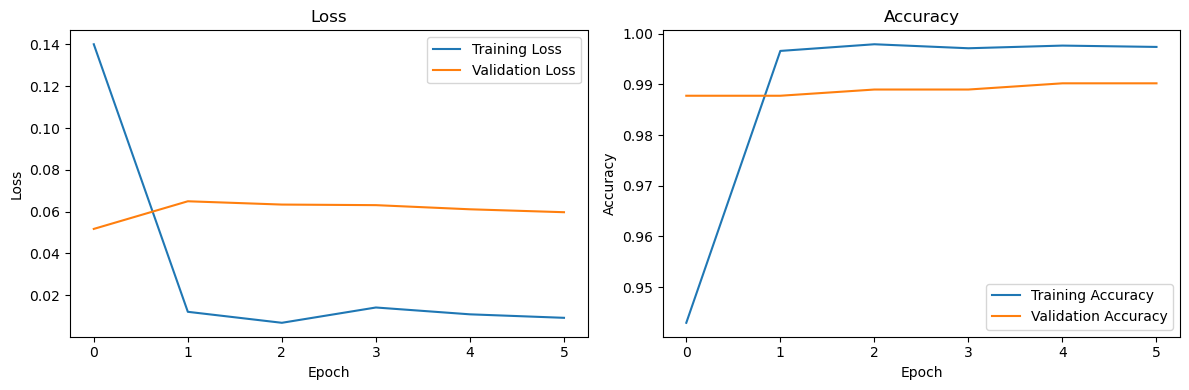

In [20]:
def build_ensemble_model(models, hp):
    inputs = [
        layers.Input(shape=model.input_shape[1:]) for model in models
    ]
    
    outputs = []
    
    for i, model in enumerate(models):
        model_copy = keras.models.clone_model(model)
        model_copy.set_weights(model.get_weights())
        
        model_copy.name = f"{model.name}_copy_{i}"
        
        model_copy.trainable = False
        
        outputs.append(model_copy(inputs[i]))
    
    if len(outputs) > 1:
        concatenated = layers.Concatenate()(outputs)
    else:
        concatenated = outputs[0]
    
    x = layers.Dense(
        hp.Int('dense_units_1', 16, 128, step=8),
        activation='relu'
    )(concatenated)
    x = layers.Dropout(hp.Float('dropout_1', 0.1, 0.5, step=0.1))(x)
    
    x = layers.Dense(
        hp.Int('dense_units_2', 16, 128, step=16),
        activation='relu'
    )(x)
    x = layers.Dropout(hp.Float('dropout_2', 0.1, 0.5, step=0.1))(x)
    
    final_output = layers.Dense(1, activation='sigmoid')(x)
    
    ensemble_model = keras.Model(inputs=inputs, outputs=final_output)
    
    ensemble_model.compile(
        optimizer=Adam(learning_rate=hp.Float('learning_rate', 1e-4, 1e-2, sampling='log')),
        loss='binary_crossentropy',
        metrics=['accuracy', keras.metrics.AUC(), keras.metrics.Precision(), keras.metrics.Recall()]
    )
    
    return ensemble_model

train_inputs = []
val_inputs = []

for name in model_names:
    if name == 'dnn':
        train_inputs.append(train_features)
        val_inputs.append(val_features)
    else:
        train_inputs.append(train_padded)
        val_inputs.append(val_padded)

tuner = kt.Hyperband(
    lambda hp: build_ensemble_model(models_to_ensemble, hp),
    objective='val_accuracy',
    max_epochs=10,
    factor=3,
    directory='../../tuner_results',
    project_name='ensemble_model'
)

early_stopping = EarlyStopping(
    monitor='val_accuracy',
    patience=2,
    restore_best_weights=True
)

print("\n=== Tuning Ensemble Model ===")
tuner.search(
    train_inputs, train_labels,
    epochs=25,
    validation_data=(val_inputs, val_labels),
    callbacks=[early_stopping],
    batch_size=32
)

best_hps = tuner.get_best_hyperparameters(num_trials=1)[0]
print(f"Best hyperparameters: {best_hps.values}")

ensemble_model = tuner.hypermodel.build(best_hps)

callbacks = [
    EarlyStopping(monitor='val_loss', patience=5, restore_best_weights=True),
    ModelCheckpoint('../../trained_models/tensorflow/ensemble_model.h5', monitor='val_loss', save_best_only=True),
    ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=3, min_lr=1e-6)
]

print("\n=== Training Ensemble Model ===")
ensemble_history = ensemble_model.fit(
    train_inputs, train_labels,
    validation_data=(val_inputs, val_labels),
    epochs=30,
    batch_size=16,
    callbacks=callbacks,
    verbose=1
)

plt.figure(figsize=(12, 4))

plt.subplot(1, 2, 1)
plt.plot(ensemble_history.history['loss'], label='Training Loss')
plt.plot(ensemble_history.history['val_loss'], label='Validation Loss')
plt.title('Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(ensemble_history.history['accuracy'], label='Training Accuracy')
plt.plot(ensemble_history.history['val_accuracy'], label='Validation Accuracy')
plt.title('Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()

plt.tight_layout()
plt.show()

ensemble_model = keras.models.load_model('../../trained_models/tensorflow/ensemble_model.h5')


## Model Evaluation

In [ ]:

test_inputs = []
for name in model_names:
    if name == 'dnn':
        test_inputs.append(test_features)
    else:
        test_inputs.append(test_padded)

print("\n=== Ensemble Model Evaluation ===")
_, ensemble_acc, ensemble_auc, ensemble_precision, ensemble_recall = ensemble_model.evaluate(
    test_inputs, test_labels
)

print(f"Ensemble Model - Test Accuracy: {ensemble_acc:.4f}, AUC: {ensemble_auc:.4f}")
print(f"Ensemble Model - Test Precision: {ensemble_precision:.4f}, Recall: {ensemble_recall:.4f}")

y_pred_prob = ensemble_model.predict(test_inputs)
y_pred = (y_pred_prob > 0.5).astype(int)

plt.figure(figsize=(8, 6))
cm = confusion_matrix(test_labels, y_pred)
sns.heatmap(
    cm, 
    annot=True, 
    fmt='d', 
    cmap='Blues',
    xticklabels=['Human', 'AI'],
    yticklabels=['Human', 'AI']
)
plt.title('Ensemble Model - Confusion Matrix')
plt.ylabel('True Label')
plt.xlabel('Predicted Label')
plt.show()

print("\nClassification Report:")
print(classification_report(test_labels, y_pred, target_names=['Human', 'AI']))

fpr, tpr, _ = roc_curve(test_labels, y_pred_prob)
roc_auc = auc(fpr, tpr)

plt.figure(figsize=(8, 6))
plt.plot(fpr, tpr, label=f'Ensemble (AUC = {roc_auc:.4f})')

for i, (name, model) in enumerate(zip(model_names, models_to_ensemble)):
    y_model_prob = model.predict(model_inputs[i])
    fpr_model, tpr_model, _ = roc_curve(test_labels, y_model_prob)
    roc_auc_model = auc(fpr_model, tpr_model)
    plt.plot(fpr_model, tpr_model, label=f'{name.upper()} (AUC = {roc_auc_model:.4f})')

plt.plot([0, 1], [0, 1], 'k--')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curves')
plt.legend(loc='lower right')
plt.show()

all_models = model_names + ['Ensemble']
all_accs = []
all_aucs = []

for i, (name, model) in enumerate(zip(model_names, models_to_ensemble)):
    _, acc, auc_score, _, _ = model.evaluate(model_inputs[i], test_labels)
    all_accs.append(acc)
    all_aucs.append(auc_score)

all_accs.append(ensemble_acc)
all_aucs.append(ensemble_auc)

plt.figure(figsize=(10, 6))
x = np.arange(len(all_models))
width = 0.35

plt.bar(x - width/2, all_accs, width, label='Accuracy')
plt.bar(x + width/2, all_aucs, width, label='AUC')

plt.xlabel('Models')
plt.ylabel('Score')
plt.title('Model Performance Comparison')
plt.xticks(x, all_models)
plt.legend()
plt.ylim(0, 1)

for i, v in enumerate(all_accs):
    plt.text(i - width/2, v + 0.01, f'{v:.4f}', ha='center')

for i, v in enumerate(all_aucs):
    plt.text(i + width/2, v + 0.01, f'{v:.4f}', ha='center')

plt.tight_layout()
plt.show()


## Model Deployment

In [ ]:
ensemble_config = {
    'model_names': model_names,
    'input_types': ['features' if name == 'dnn' else 'sequences' for name in model_names],
    'tokenizer': tokenizer,
    'max_seq_length': max_seq_length,
    'clean_text': clean_text,
    'extract_features': extract_features
}

with open('../../trained_models/tensorflow/ensemble_config.pkl', 'wb') as f:
    pickle.dump(ensemble_config, f)

print("Ensemble configuration saved to '../../trained_models/tensorflow/ensemble_config.pkl'")

def predict_text(text, ensemble_model, config, base_models):
    cleaned_text = config['clean_text'](text)
    
    inputs = []
    
    for i, input_type in enumerate(config['input_types']):
        if input_type == 'features':
            features = config['extract_features']([cleaned_text])
            inputs.append(features)
        else:
            sequence = config['tokenizer'].texts_to_sequences([cleaned_text])
            padded = pad_sequences(sequence, maxlen=config['max_seq_length'], padding='post', truncating='post')
            inputs.append(padded)
    
    prediction = ensemble_model.predict(inputs)[0][0]
    
    individual_preds = {}
    for i, (name, model) in enumerate(zip(config['model_names'], base_models)):
        individual_preds[name] = float(model.predict(inputs[i])[0][0])
    
    return {
        'ensemble_probability': float(prediction),
        'ensemble_prediction': 'AI' if prediction > 0.5 else 'Human',
        'individual_predictions': individual_preds
    }

sample_text = "This is a sample text to test the ensemble model."
result = predict_text(sample_text, ensemble_model, ensemble_config, models_to_ensemble)

print(f"Sample text: '{sample_text}'")
print(f"Ensemble prediction: {result['ensemble_prediction']} (Probability: {result['ensemble_probability']:.4f})")
print("Individual model predictions:")
for name, prob in result['individual_predictions'].items():
    pred = 'AI' if prob > 0.5 else 'Human'
    print(f"  - {name.upper()}: {pred}")
